In [1]:
from random import shuffle

import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

from transformers import DistilBertTokenizer, DistilBertModel
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast, Trainer, TrainingArguments

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import Accuracy
from torch.utils.data import DataLoader

In [2]:
df1 = pd.read_csv("data.csv")
df1.head()

,Phrase,Intentionality
0,"I'm not entirely sure, but I think it's worth ...",Indecisive
1,"I could go either way on this, honestly.",Indecisive
2,"I’m not sure what to choose, they both seem good.",Indecisive
3,"I guess we could try it, but I’m still thinkin...",Indecisive
4,"I’m torn between the two options, I don’t know...",Indecisive


In [3]:
tint = pd.read_csv("tint.csv")
tint.head()

,tint,antonym
0,Curious,Disinterested
1,Sincere,Hypocritical
2,Responsible,Irresponsible
3,Goal-oriented,Aimless
4,Objective,Biased


In [4]:
df_train, df_test = train_test_split(df1, test_size=0.4)
df_valid, df_test = train_test_split(df_test, test_size=0.7)

df_train.head()

,Phrase,Intentionality
895,That was a bit of a letdown.,Disappointing
2632,I’m afraid I’ll say the wrong thing.,Timid
1575,I’m prioritizing logic and reasoning in our ap...,Objective
1157,"Let me hear all of it, I’m listening intently.",Attentive
3486,"Sure, whatever.",Indifferent


In [5]:
df_train.describe()

,Phrase,Intentionality
count,3229,3229
unique,3207,104
top,It doesn’t matter to me.,Confident
freq,2,62


<AxesSubplot:>

c:\Users\sebas\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\sebas\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


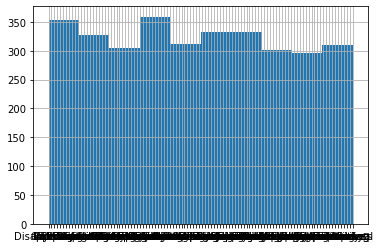

In [6]:
df_train['Intentionality'].hist()

In [7]:
def tint_coding(x, t, antonim):
    if x == t:
        return 1
    elif x == antonim:
        return -1
    else:
        return 0

def preprocess_data(df, tint):
    data_preprocess = []

    for t, antonim in tint.values:
        cur_df = df.copy()
        cur_df['Intentionality'] = cur_df['Intentionality'].apply(lambda x: tint_coding(x, t, antonim))

        true_labels = cur_df[(cur_df['Intentionality'] == 1) | (cur_df['Intentionality'] == -1)]
        false_labels = cur_df[cur_df['Intentionality'] == 0].sample(len(true_labels)*4, random_state=42)

        data = pd.concat([true_labels, false_labels], ignore_index=True)
        data_preprocess.append(data)

    return data_preprocess

In [8]:
class TorchSet(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.tokenizer = tokenizer
        self.phrase = tokenizer(df['Phrase'].tolist(), truncation=True, padding=True)
        self.tint = df['Intentionality'].values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.phrase.items()}
        item['labels'] = torch.tensor(self.tint[idx])
        return item

    def __len__(self):
        return len(self.tint)

In [9]:
def get_torchset(data_preprocess, tokenizer):
    datasets = []

    for data in data_preprocess:
        dataset = TorchSet(data, tokenizer)
        loader = DataLoader(dataset, batch_size=30, shuffle=True)
        datasets.append(loader)

    return datasets

In [10]:
# model

In [11]:
class Classifier(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # self.model = model
        self.tanh = nn.Tanh()
        self.layer1 = nn.Sequential(
            nn.Linear(in_features=768, out_features=768//2),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=768//2, out_features=768//4),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(in_features=768//4, out_features=1),
            # nn.Tanh()
        )

        nn.init.kaiming_uniform_(self.layer1[0].weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.layer2[0].weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.layer3[0].weight)



    def forward(self, x, tanh=False):
        # x = model(**x)
        # print(x)
        x = F.avg_pool1d(x[0].permute(0, 2, 1), kernel_size=x[0].size(1)).squeeze(-1)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        if tanh:
            x = self.tanh(x)
        return x

In [12]:
class Tint(nn.Module):
    def __init__(self, bert, n_heads=52):
        super().__init__()

        self.n_heads = n_heads
        self.bert = bert
        self.heads = nn.ModuleList([Classifier() for _ in range(n_heads)])

    def forward(self, x, tanh=False, head_num=0):
        head = self.heads[head_num]

        x = self.bert(**x)
        x = head(x, tanh=tanh)

        return x

In [13]:
class TintLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_gt):
        loss = torch.log(torch.exp(-1 * y_pred * y_gt) + 1).mean()
        return loss

In [14]:
l = TintLoss()
print(l(torch.Tensor([-10]), torch.Tensor([1])).item())
print(l(torch.Tensor([-10]), torch.Tensor([-1])).item())
print(l(torch.Tensor([10]), torch.Tensor([-1])).item())
print(l(torch.Tensor([10]), torch.Tensor([1])).item())

10.000045776367188
4.541770613286644e-05
10.000045776367188
4.541770613286644e-05


In [15]:
def output_process(x):
    if x < -0.3:
        return -1
    elif x > 0.3:
        return 1
    else:
        return 0

In [ ]:
def model_train(train, valid, model, device=torch.device('cuda'), num_epoch=10, lr=0.01):
    train_losses = []
    valid_losses = []

    train_accuracies = []
    valid_accuracies = []

    n_heads = model.n_heads
    model.to(device)

    tanh = nn.Tanh()
    accuracy = Accuracy(task='multiclass', num_classes=3)

    optimizers = []
    for i in range(n_heads):
        optimizer = torch.optim.Adam([
                                    {'params': model.bert.parameters(), 'lr': 0.01},
                                    {'params': model.heads[i].parameters(), 'lr': lr,
                                    'weight_decay': 0.2}
                                    ])
        optimizers.append(optimizer)

    loss_func = TintLoss()

    for epoch in tqdm(range(num_epoch)):
        model.train()

        cur_train_accuracy = [0] * n_heads
        cur_valid_accuracy = [0] * n_heads

        cur_train_losses = [0] * n_heads
        cur_valid_losses = [0] * n_heads

        idx_list = list(range(n_heads))
        shuffle(idx_list)

        k = 0
        for i in idx_list:
            print(k)
            k += 1

            # if k == 10:
            #     torch.cuda.memory._dump_snapshot(f"{'cuda_history'}.pickle")
            #     torch.cuda.memory._record_memory_history(enabled=None)


            train_loader = train[i]
            valid_loader = valid[i]

            batch_acc_mean = []
            # total_train = 0
            total_loss = 0

            optimizers[i].zero_grad(set_to_none=True)
            for batch in train_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                x = {}
                x['input_ids'] = batch['input_ids']
                x['attention_mask'] = batch['attention_mask']

                y = batch['labels']
                y_pred = model(x, tanh=False, head_num=i)

                loss = loss_func(y_pred, y)

                loss.backward()
                total_loss += loss.item()
                # torch.nn.utils.clip_grad_value_(model.parameters(), 30.0)
                optimizers[i].step()
                optimizers[i].zero_grad(set_to_none=True)

                # print(loss, loss.grad)
                # loss.to(torch.device('cpu'))
                # x['input_ids'].to(torch.device('cpu'))
                # x['attention_mask'].to(torch.device('cpu'))
                y_cpu = y.to(torch.device('cpu'))
                y_pred_cpu = y_pred.to(torch.device('cpu'))

                # del x['input_ids'], x['attention_mask'], y, y_pred, loss, batch['input_ids'], batch['attention_mask'], batch['labels'], x, batch
                # torch.cuda.empty_cache()


            #     y_pred_cpu = tanh(y_pred_cpu)
            #     y_pred_cpu = torch.squeeze(y_pred_cpu)
            #     y_pred_processed = y_pred_cpu.detach().apply_(output_process)

            #     batch_acc = accuracy(y_pred_processed, y_cpu)
            #     batch_acc_mean.append(batch_acc)



            #     # _, predicted = torch.max(y_pred.data, 1)
            #     # _, true_value = torch.max(y.data, 1)
            #     # total_train += y.size(0)
            #     # correct_train += (predicted == true_value).sum().item()

            # # optimizers[i].zero_grad()

            # train_accuracy = torch.tensor(batch_acc_mean).mean() * 100
            # print(train_accuracy)
            # cur_train_accuracy[i] = train_accuracy
            # cur_train_losses[i] = total_loss


            model.eval()
            batch_acc_mean = []
            total_valid = 0
            total_loss = 0

            with torch.no_grad():
                for batch in valid_loader:
                    batch = {k: v.to(device) for k, v in batch.items()}
                    x = {}
                    x['input_ids'] = batch['input_ids']
                    x['attention_mask'] = batch['attention_mask']

                    y = batch['labels']
                    y_pred = model(x, tanh=False, head_num=i)

                    loss = loss_func(y_pred, y)
                    # loss = loss_func_mse(y_pred, y)
                    total_loss += loss.item()

                    # loss.to(torch.device('cpu'))
                    # x['input_ids'].to(torch.device('cpu'))
                    # x['attention_mask'].to(torch.device('cpu'))
                    y_cpu = y.to(torch.device('cpu'))
                    y_pred_cpu = y_pred.to(torch.device('cpu'))

                    # del x['input_ids'], x['attention_mask'], y, y_pred, loss
                    # torch.cuda.empty_cache()

        #             y_pred_cpu = tanh(y_pred_cpu)
        #             y_pred_cpu = torch.squeeze(y_pred_cpu)
        #             y_pred_processed = y_pred_cpu.detach().apply_(output_process)
        #             batch_acc = []

        #             batch_acc = accuracy(y_pred_processed, y_cpu)

        #             batch_acc_mean.append(batch_acc)

        #             # _, predicted = torch.max(y_pred.data, 1)
        #             # _, true_value = torch.max(y.data, 1)
        #             # total_valid += y.size(0)
        #             # correct_valid += (predicted == true_value).sum().item()

        #     valid_accuracy = torch.tensor(batch_acc_mean).mean() * 100
        #     cur_valid_accuracy[i] = valid_accuracy
        #     cur_valid_losses[i] = total_loss

        # train_accuracies.append(cur_train_accuracy)
        # valid_accuracies.append(cur_valid_accuracy)

        # train_losses.append(torch.tensor(cur_train_losses).mean())
        # train_losses.append(torch.tensor(cur_valid_losses).mean())

        # if epoch % 5 == 0:
        #     print(f'Epoch {epoch+1}/{num_epoch}, Train Accuracy: {torch.tensor(cur_train_losses).mean():.2f}%, Valid Accuracy: {torch.tensor(cur_valid_losses).mean():.2f:.2f}%')

    return train_losses, valid_losses, train_accuracies, valid_accuracies

In [17]:
model = DistilBertModel.from_pretrained("distilbert-base-uncased")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

c:\Users\sebas\anaconda3\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [18]:
train_preprocess = preprocess_data(df_train, tint)
valid_preprocess = preprocess_data(df_valid, tint)

train = get_torchset(train_preprocess, tokenizer)
valid = get_torchset(valid_preprocess, tokenizer)

clf = Tint(model)

In [19]:
param = {'train': train,
         'valid': valid,
         'model': clf,
         'num_epoch': 1,
         'lr': 0.1}

# torch.cuda.memory._record_memory_history(max_entries=100000)

result = model_train(**param)

  0%|          | 0/1 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 10.40 GiB is allocated by PyTorch, and 415.85 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
def visualize_losses(losses, title, loc):

    t = np.arange(1, len(losses[0]) + 1)
    plt.figure(figsize=(12, 8))
    plt.plot(t, losses[0], label = "train")
    plt.plot(t, losses[1], label = "valid")

    plt.legend(fontsize=20, loc=loc)
    plt.xlabel("t")
    plt.ylabel("$E(t)$")
    plt.title(title)
    plt.show()

In [ ]:
result[0]
result[1]

In [ ]:
visualize_losses(result[:2], title='Losses', loc='upper right')
visualize_losses(result[2:], title='Accuracy', loc='lower right')

In [ ]:
device = torch.device("cuda")
with torch.no_grad():
    for batch in valid_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        x = {}
        x['input_ids'] = batch['input_ids']
        x['attention_mask'] = batch['attention_mask']

        y_pred = clf(x, tanh=False)

        tanh = nn.Tanh()
        print(tanh(y_pred))